# ppa-lab playground

A **living notebook**: one section per sprint day, extended as the project grows. Use it
to look at the data, change parameters, and try your own ideas.

| | Where |
|---|---|
| Graded exercises (with automatic checks) | `exercises/dayNN_*.py`. The notebook does **not** solve them; its **✅ My solutions** blocks import *your* answers from there once you have written them |
| Explanations | `docs/learning_track/dayNN_*.md` |
| What every column means | `docs/data_dictionary.md` |

**How to use it**

1. The processed data must exist (`make all` once).
2. Open it with `make notebook` (JupyterLab), or in VS Code: open this file and pick the
   `.venv` interpreter as the kernel.
3. Run the cells **top to bottom** (Shift+Enter). Section 0 loads everything once.
4. Cells marked **🎛 Play** have parameters in CAPITALS at the top: change them and re-run
   the cell. **✍ Your turn** cells are empty, for your own code.
5. Broke something? *Kernel → Restart Kernel and Run All Cells* gets you back to a clean state.

**Contents:** 0. Setup · Day 1: market data (1.1-1.6, ✅ my solutions) · Day 2: capture prices (2.1-2.8, ✅ my solutions) · Day 3+: added on those days

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ppa_lab.config import load_settings
from ppa_lab.analysis.reconcile import annual_price_stats, monthly_mean_price, reconcile
from ppa_lab.analysis.capture import (
    TECHNOLOGIES, capture_table, compare_monthly, load_market_values, prices_on_grid,
)

%matplotlib inline
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({
    "figure.figsize": (10, 3.6), "axes.grid": True, "grid.color": "#e2e2de",
    "axes.spines.top": False, "axes.spines.right": False, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlesize": 11,
})

s = load_settings()                     # every path and assumption comes from config/project.toml
TZ = s.timezone                         # "Europe/Berlin"
COLOURS = {"wind_onshore": "#2a78d6", "solar": "#eb6834", "wind_offshore": "#1baf7a"}
LABELS = {"solar": "Solar", "wind_onshore": "Wind onshore", "wind_offshore": "Wind offshore"}
YEAR_COLOURS = {2023: "#86b6ef", 2024: "#3987e5", 2025: "#1c5cab", 2026: "#0d366b"}   # light -> dark
print("Processed data:", s.processed_dir)

Processed data: /Users/ap/Desktop/Work_25_02/Claude/JobHunt/Encavis quantitative/ppa-lab/data/processed


In [2]:
# Load the four processed datasets once. The files are in UTC; the *_loc views are in local
# time, which is what you need to select a day, month or year.
prices   = pd.read_parquet(s.processed_dir / "prices_native.parquet")   # 60 min until Sep 2025, then 15 min
prices_h = pd.read_parquet(s.processed_dir / "prices_hourly.parquet")
power    = pd.read_parquet(s.processed_dir / "power_15min.parquet")
power_h  = pd.read_parquet(s.processed_dir / "power_hourly.parquet")

prices_loc, prices_h_loc = prices.tz_convert(TZ), prices_h.tz_convert(TZ)
power_loc, power_h_loc = power.tz_convert(TZ), power_h.tz_convert(TZ)

for name, df in [("prices", prices), ("prices_h", prices_h), ("power", power), ("power_h", power_h)]:
    local = df.index.tz_convert(TZ)
    print(f"{name:9s} {len(df):>8,} rows x {df.shape[1]:>2} cols   {local.min():%Y-%m-%d %H:%M} -> {local.max():%Y-%m-%d %H:%M}")

prices      59,135 rows x  2 cols   2023-01-01 00:00 -> 2026-09-30 23:45
prices_h    32,855 rows x  2 cols   2023-01-01 00:00 -> 2026-09-30 23:00
power      131,420 rows x 22 cols   2023-01-01 00:00 -> 2026-09-30 23:45
power_h     32,855 rows x 22 cols   2023-01-01 00:00 -> 2026-09-30 23:00


### Helpers for the ✅ My solutions sections
At the end of each day, a **My solutions** block imports *your* code from `exercises/`, shows it,
runs the automatic checks and extends your results. The exercise files stay the single source
of truth: edit them there, re-run the cells here.

In [3]:
import importlib, inspect, os, subprocess, sys
from IPython.display import Code, Markdown, display

ROOT = s.processed_dir.parents[1]          # repository root
EXERCISES = ROOT / "exercises"
if str(EXERCISES) not in sys.path:
    sys.path.insert(0, str(EXERCISES))


def load_exercises(module_name):
    "Import an exercise file; re-imported every time, so your latest edits are used."
    return importlib.reload(importlib.import_module(module_name))


def run_checks(test_file):
    "Run the automatic checks of one exercise file: ✅ passed, ⏳ not solved yet, ❌ wrong."
    cmd = [sys.executable, "-m", "pytest", str(EXERCISES / test_file), "-o", "addopts=", "-v",
           "--tb=no", "-rfs", "--color=no", "-p", "no:cacheprovider"]
    wide = {**os.environ, "COLUMNS": "400"}   # pytest shortens summary lines to the terminal width
    out = subprocess.run(cmd, cwd=ROOT, env=wide, capture_output=True, text=True).stdout.splitlines()
    reasons = {line.split("::")[1].split(" ")[0]: line for line in out if line.startswith("FAILED")}
    for line in out:
        if "::" not in line or line.startswith(("FAILED", "SKIPPED")):
            continue
        name = line.split("::")[1].split(" ")[0]
        if " PASSED" in line:
            print(f"✅ {name}")
        elif " SKIPPED" in line:
            print(f"⏭ {name}: skipped (processed data missing?)")
        elif "NotImplementedError" in reasons.get(name, ""):
            print(f"⏳ {name}: not solved yet")
        elif " FAILED" in line:
            print(f"❌ {name}: {reasons.get(name, '').split(' - ', 1)[-1]}")


def solution(func, *args, **kwargs):
    "Show your code and run it. Returns None if it is not solved yet or raises an error."
    try:
        result = func(*args, **kwargs)
    except NotImplementedError:
        display(Markdown(f"⏳ `{func.__name__}`: not solved yet"))
        return None
    except Exception as err:  # a bug in the exercise code: show it, keep the notebook running
        display(Code(inspect.getsource(func), language="python"))
        display(Markdown(f"❌ `{func.__name__}` raised **{type(err).__name__}**: {err}. "
                         "Fix it in the exercise file and re-run this cell."))
        return None
    display(Code(inspect.getsource(func), language="python"))
    return result


def show_text(text):
    "Display a written answer as a quote, or a reminder if it is still empty."
    display(Markdown("> " + text.replace("\n", "\n> ") if text and text.strip() else "⏳ not written yet"))


def show_written_answer(exercise_file, marker):
    "Show the comment lines that follow `marker` in an exercise file."
    lines = (EXERCISES / exercise_file).read_text().splitlines()
    start = next(i for i, line in enumerate(lines) if line.strip() == marker) + 1
    answer = []
    for line in lines[start:]:
        if not line.startswith("#"):
            break
        answer.append(line[1:].strip())
    show_text("\n".join(answer).strip())

---
# Day 1: market-data foundation (PPA-1)

German day-ahead prices and generation since 2023, checked and reconciled.
Background: `docs/learning_track/day01_market_data_foundation.md`.

### 1.1 First look at the data

In [4]:
prices_loc.head()          # price_eur_mwh + interval_min (60 = hourly product, 15 = quarter-hour)

,price_eur_mwh,interval_min
ts_utc,,
2023-01-01 00:00:00+01:00,-5.17,60.0
2023-01-01 01:00:00+01:00,-1.07,60.0
2023-01-01 02:00:00+01:00,-1.47,60.0
2023-01-01 03:00:00+01:00,-5.08,60.0
2023-01-01 04:00:00+01:00,-4.49,60.0


In [5]:
# 22 columns of power in MW (average over the interval). See docs/data_dictionary.md.
power_h_loc.describe().T[["min", "mean", "max"]].round(0)

,min,mean,max
hydro_pumped_storage_consumption_mw,-7120.0,-1468.0,0.0
cross_border_electricity_trading_mw,-19434.0,1894.0,17082.0
nuclear_mw,271.0,2671.0,3075.0
hydro_run_of_river_mw,912.0,1955.0,2994.0
biomass_mw,2442.0,4120.0,5710.0
fossil_brown_coal_lignite_mw,1357.0,8050.0,17131.0
fossil_hard_coal_mw,125.0,3213.0,13450.0
fossil_oil_mw,37.0,342.0,1343.0
fossil_coal_derived_gas_mw,125.0,507.0,917.0
fossil_gas_mw,834.0,5238.0,17624.0


In [6]:
# Annual energy in TWh: hourly MW = MWh per hour, so sum and divide by 1e6.
energy_twh = power_h_loc[["solar_mw", "wind_onshore_mw", "wind_offshore_mw", "fossil_brown_coal_lignite_mw",
                          "fossil_hard_coal_mw", "fossil_gas_mw", "biomass_mw", "load_mw"]]
energy_twh.groupby(energy_twh.index.year).sum().div(1e6).round(1)

,solar_mw,wind_onshore_mw,wind_offshore_mw,fossil_brown_coal_lignite_mw,fossil_hard_coal_mw,fossil_gas_mw,biomass_mw,load_mw
ts_utc,,,,,,,,
2023,53.9,115.9,23.5,77.6,33.4,40.0,36.6,458.4
2024,59.7,110.6,25.7,71.1,23.8,43.6,37.0,465.5
2025,70.1,105.1,26.1,67.2,26.6,49.5,36.1,465.8
2026,76.2,77.7,20.5,48.6,21.8,39.0,25.6,346.5


### 1.2 Time: daylight saving and the 15-minute switch
A local delivery day has 23, 24 or 25 hours, and since 1 Oct 2025 prices come in quarter-hours.
Count the price intervals per local day:

In [7]:
rows_per_day = prices_loc.groupby(prices_loc.index.date).size()
for day, why in [("2025-03-30", "spring DST: 23 hours"), ("2025-06-15", "normal day"),
                 ("2025-10-01", "first quarter-hour day: 96"), ("2025-10-26", "autumn DST: 25 x 4")]:
    print(f"{day}  {rows_per_day[pd.Timestamp(day).date()]:>3} price intervals   ({why})")

2025-03-30   23 price intervals   (spring DST: 23 hours)
2025-06-15   24 price intervals   (normal day)
2025-10-01   96 price intervals   (first quarter-hour day: 96)
2025-10-26  100 price intervals   (autumn DST: 25 x 4)


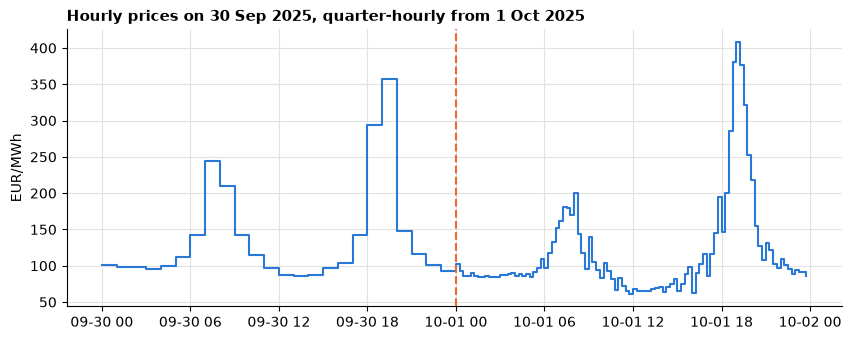

In [8]:
window = prices_loc.loc["2025-09-30":"2025-10-01", "price_eur_mwh"]
fig, ax = plt.subplots()
ax.step(window.index, window, where="post", color="#2a78d6")
ax.axvline(pd.Timestamp("2025-10-01", tz=TZ), color="#eb6834", linestyle="--")
ax.set_title("Hourly prices on 30 Sep 2025, quarter-hourly from 1 Oct 2025")
ax.set_ylabel("EUR/MWh");

### 1.3 Prices over time
`monthly_mean_price` is time-weighted, so hourly and quarter-hourly months are comparable.

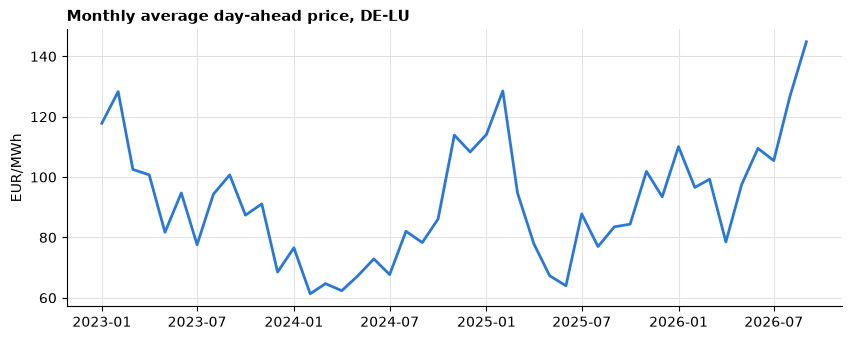

In [9]:
monthly_price = monthly_mean_price(prices, TZ)
fig, ax = plt.subplots()
ax.plot(monthly_price.index.to_timestamp(), monthly_price, color="#2a78d6", linewidth=2)
ax.set_title("Monthly average day-ahead price, DE-LU")
ax.set_ylabel("EUR/MWh");

In [10]:
stats = annual_price_stats(prices, TZ)
stats[["mean_price_eur_mwh", "min_price_eur_mwh", "max_price_eur_mwh", "negative_hours",
       "longest_negative_streak_h"]].round(2)

,mean_price_eur_mwh,min_price_eur_mwh,max_price_eur_mwh,negative_hours,longest_negative_streak_h
year,,,,,
2023,95.18,-500.00,524.27,301,36
2024,78.51,-135.45,936.28,457,18
2025,89.32,-250.32,583.40,576,20
2026,107.72,-499.99,747.10,471,18


### 1.4 🎛 Play: look at any week
Change `START` and `DAYS`, then re-run. Try a windy winter week, a sunny May weekend or Christmas.

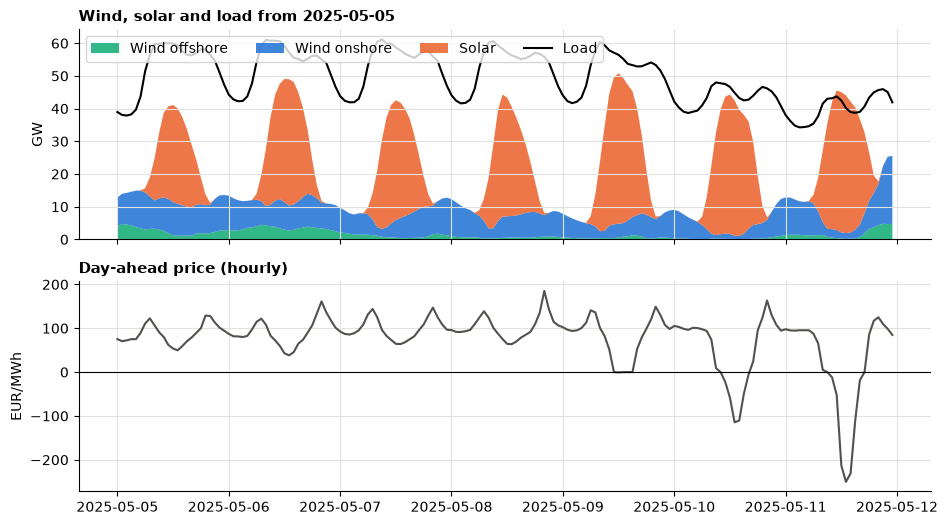

In [11]:
START = "2025-05-05"       # local date, YYYY-MM-DD
DAYS = 7

last = (pd.Timestamp(START) + pd.Timedelta(days=DAYS - 1)).strftime("%Y-%m-%d")   # inclusive
g = power_h_loc.loc[START:last]
p = prices_h_loc.loc[START:last, "price_eur_mwh"]

fig, (top, bottom) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
top.stackplot(g.index, g["wind_offshore_mw"] / 1e3, g["wind_onshore_mw"] / 1e3, g["solar_mw"] / 1e3,
              colors=[COLOURS["wind_offshore"], COLOURS["wind_onshore"], COLOURS["solar"]],
              labels=["Wind offshore", "Wind onshore", "Solar"], alpha=0.9)
top.plot(g.index, g["load_mw"] / 1e3, color="black", linewidth=1.5, label="Load")
top.set_ylabel("GW"); top.set_title(f"Wind, solar and load from {START}"); top.legend(loc="upper left", ncols=4)
bottom.plot(p.index, p, color="#52514e"); bottom.axhline(0, color="black", linewidth=0.8)
bottom.set_ylabel("EUR/MWh"); bottom.set_title("Day-ahead price (hourly)");

### 1.5 The merit order in real data: price vs residual load
Residual load = load − wind − solar: what the rest of the system must cover. Low residual
load means cheap (or negative) prices; high residual load means gas sets the price.

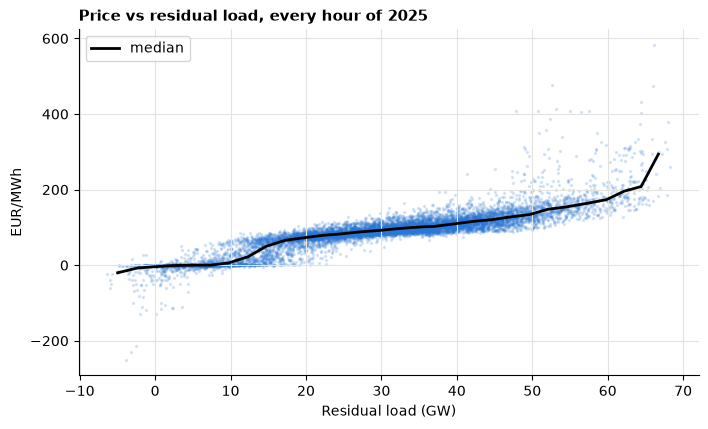

In [12]:
YEAR = "2025"
both = prices_h_loc.loc[YEAR, ["price_eur_mwh"]].join(power_h_loc.loc[YEAR, ["residual_load_mw"]]).dropna()
bins = pd.cut(both["residual_load_mw"], 30)
median = both.groupby(bins, observed=True).median()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(both["residual_load_mw"] / 1e3, both["price_eur_mwh"], s=2, alpha=0.15, color="#2a78d6")
ax.plot(median["residual_load_mw"] / 1e3, median["price_eur_mwh"], color="black", linewidth=2, label="median")
ax.set_xlabel("Residual load (GW)"); ax.set_ylabel("EUR/MWh"); ax.legend()
ax.set_title(f"Price vs residual load, every hour of {YEAR}");

### 1.6 Reconciliation with published figures (Day 1 references)
`status` is *within tolerance*, *explained difference* (cause documented in `config/project.toml`)
or *OUTSIDE tolerance*.

In [13]:
day1_refs = [r for r in s.references if r.metric in stats.columns]
reconcile(stats, day1_refs)[["metric", "year", "ours", "published", "difference", "tolerance", "status"]].round(2)

,metric,year,ours,published,difference,tolerance,status
0,mean_price_eur_mwh,2025,89.32,89.32,0.00,0.5,within tolerance
1,mean_price_eur_mwh,2024,78.51,79.46,-0.95,0.5,explained difference
2,mean_price_eur_mwh,2023,95.18,95.18,-0.00,0.5,within tolerance
3,negative_hours,2025,576.00,575.00,1.00,5.0,within tolerance
4,negative_hours,2024,457.00,459.00,-2.00,5.0,within tolerance
5,negative_hours,2023,301.00,301.00,0.00,5.0,within tolerance


### Day 1: play ideas (no answers here, explore)
- Which local **day** had the lowest average price in each year? Plot it with 1.4 (`DAYS = 1`).
- How many hours per year had a price **above 300 EUR/MWh**? In which months?
- Compare the average **hourly profile** of a winter month and a summer month.
- In 1.5, change `YEAR` to `"2023"`: how did the curve move, and why (gas prices)?
- Find the hour with the **highest residual load** in 2025. What was the price?

#### ✍ Your turn (Day 1)

In [14]:
# your code here

### ✅ My solutions: Day 1 warm-up
Live from `exercises/day01_warmup.py`: edit that file, then re-run these cells. The automatic
checks run first, then each exercise shows your code and its results (extended to more years).

In [15]:
ex1 = load_exercises("day01_warmup")
run_checks("test_day01_warmup.py")

✅ test_ex1_peak_base_2025
✅ test_ex1_peak_premium_shrank_since_2023
✅ test_ex2_extreme_hours_2025
✅ test_ex3_solar_energy_2025


**Exercise 1: peak vs base**, for every full year. Watch the peak premium shrink.

In [16]:
if solution(ex1.peak_base, prices_h, 2025) is not None:
    table = pd.DataFrame({y: ex1.peak_base(prices_h, y) for y in (2023, 2024, 2025)}).T
    table["peak_premium"] = table["peak"] - table["base"]
    display(table.round(2))

def peak_base(hourly: pd.DataFrame, year: int) -> dict[str, float]:
    """Average base, peak and off-peak price for one calendar year.

    EEX definition: Peak = Monday-Friday, 08:00-20:00 local time
    (hours starting 08:00 up to and including the hour starting 19:00).
    Off-peak = every other hour. Base = all hours.

    Return {"base": ..., "peak": ..., "offpeak": ...} in EUR/MWh.

    Hints:
      1. Convert the index to local time first: hourly.tz_convert(TZ)
      2. Select the year with .loc[str(year)]
      3. DatetimeIndex has .dayofweek (Monday = 0) and .hour
      4. Build a boolean mask for peak, then use mask and ~mask
    """
    local = hourly.tz_convert(TZ).loc[str(year)]
    idx = local.index
    peak = (
        (idx.dayofweek  < 5)
        & (idx.hour >= 8)
        & (idx.hour < 20)
    )

    prices = local["price_eur_mwh"]

    return {
        "base": prices.mean(),
        "peak": prices[peak].mean(),
        "offpeak": prices[~peak].mean()
    }

,base,peak,offpeak,peak_premium
2023,95.18,106.24,89.06,11.06
2024,78.51,87.85,73.30,9.34
2025,89.32,92.35,87.64,3.03


**Exercise 2: the extreme hours of 2025**, the state of the system at those hours (GW), and
your merit-order explanation.

In [17]:
extremes = solution(ex1.extreme_hours, prices_h, 2025)
if extremes is not None:
    at = [extremes["min_time"], extremes["max_time"]]
    state = power_h_loc.loc[at, ["solar_mw", "wind_onshore_mw", "wind_offshore_mw", "load_mw",
                                 "residual_load_mw"]].div(1e3).round(1)
    state.columns = [c.replace("_mw", "_gw") for c in state.columns]
    state.insert(0, "price_eur_mwh", [extremes["min_price"], extremes["max_price"]])
    state.index = [f"lowest: {at[0]:%a %d %b %Y %H:%M}", f"highest: {at[1]:%a %d %b %Y %H:%M}"]
    display(state)
show_text(inspect.getdoc(ex1.main).split("\n\n", 1)[-1])

def extreme_hours(hourly: pd.DataFrame, year: int) -> dict[str, object]:
    """Lowest and highest hourly price of a year, with their local start times.

    Return {"min_time": Timestamp, "min_price": float,
            "max_time": Timestamp, "max_price": float}
    where the times are tz-aware in Europe/Berlin.

    Hints: .idxmin() / .idxmax() return the index label of the extreme value.
    Afterwards, look up solar, wind and load at those hours in
    power_hourly.parquet and explain the prices with the merit order
    (write your explanation in the docstring of `main` below).
    """
    local = hourly.tz_convert(TZ).loc[str(year)]
    prices = local["price_eur_mwh"]
    min_time = prices.idxmin()
    max_time = prices.idxmax()
    return {
        "min_time": min_time,
        "min_price": float(prices.loc[min_time]),
        "max_time": max_time,
        "max_price": float(prices.loc[max_time]),
    }

,price_eur_mwh,solar_gw,wind_onshore_gw,wind_offshore_gw,load_gw,residual_load_gw
lowest: Sun 11 May 2025 13:00,-250.32,42.1,1.8,0.2,40.1,-3.9
highest: Mon 20 Jan 2025 17:00,583.40,0.0,2.7,1.8,70.6,66.1


> My merit-order explanation of the two extreme hours (Exercise 2):
> - Lowest hour: On a sunny Sunday, solar generation (42 GW) exceeded total
>   demand (40 GW). The surplus pushed the price below zero because subsidised
>   and inflexible plants kept producing and there was too little storage,
>   export or flexible demand.
> - Highest hour: On a winter weekday evening there was no sun and little wind
>   (4.5 GW) against 71 GW of demand, so the market had to use the most
>   expensive plants (gas peakers, oil, imports); the marginal plant set the
>   price for everyone.

**Exercise 3: units drill**, solar energy per year.

In [18]:
if solution(ex1.solar_twh, power, 2025) is not None:
    display(pd.Series({y: round(ex1.solar_twh(power, y), 1) for y in (2023, 2024, 2025)}, name="solar TWh"))

def solar_twh(power_15min: pd.DataFrame, year: int) -> float:
    """Total German public net solar generation in one year, in TWh.

    The data is average POWER (MW) per 15-minute interval.
    Energy per interval = MW x 0.25 h = MWh.  1 TWh = 1,000,000 MWh.

    Pitfall to avoid: summing MW values directly gives a number 4x too large
    (and with the wrong unit).
    """
    local = power_15min.tz_convert(TZ).loc[str(year)]
    solar_mw = local["solar_mw"]
    return solar_mw.sum() * 0.25 / 1_000_000

2023    53.9
2024    59.7
2025    70.1
Name: solar TWh, dtype: float64

---
# Day 2: capture prices and capture rates (PPA-2)

What solar and wind really earn compared with baseload, reconciled against the official
German market values. Background: `docs/learning_track/day02_capture_prices.md`.

### 2.1 The formula on the worked example from the learning track

In [19]:
example = pd.DataFrame({"price_eur_mwh": [10, 100, 10, 100], "solar_mwh": [300, 100, 300, 100]},
                       index=["11:00", "11:15", "11:30", "11:45"])
base = example["price_eur_mwh"].mean()                                         # flat band
capture = (example["price_eur_mwh"] * example["solar_mwh"]).sum() / example["solar_mwh"].sum()
print(f"base {base:.1f} EUR/MWh | capture {capture:.1f} EUR/MWh | capture rate {capture / base:.2f}")
example

base 55.0 EUR/MWh | capture 32.5 EUR/MWh | capture rate 0.59


,price_eur_mwh,solar_mwh
11:00,10,300
11:15,100,100
11:30,10,300
11:45,100,100


### 2.2 Prices on the 15-minute generation grid
Generation is quarter-hourly; prices were hourly until 30 Sep 2025. `prices_on_grid` gives each
quarter-hour the price of the interval that contains it (and leaves gaps empty).

In [20]:
grid = power.index
on_grid = prices_on_grid(prices, grid).tz_convert(TZ)
pd.concat({"30 Sep 2025 (hourly price)": on_grid.loc["2025-09-30 10:00":"2025-09-30 10:45"].reset_index(drop=True),
           "1 Oct 2025 (quarter-hour prices)": on_grid.loc["2025-10-01 10:00":"2025-10-01 10:45"].reset_index(drop=True)},
          axis=1).set_index(pd.Index(["10:00", "10:15", "10:30", "10:45"]))

,30 Sep 2025 (hourly price),1 Oct 2025 (quarter-hour prices)
10:00,115.2,103.22
10:15,115.2,93.06
10:30,115.2,81.21
10:45,115.2,66.65


### 2.3 The capture tables
`capture_table` returns one row per (local period, technology). See the data dictionary for the columns.

In [21]:
monthly = capture_table(prices, power, TZ, freq="M")
annual = capture_table(prices, power, TZ, freq="Y")
annual.round(3)

base_price_eur_mwh  capture_price_eur_mwh  capture_rate  energy_twh  negative_price_share
period technology                                                                                              
2023   solar                      95.175                 72.247         0.759      53.907                 0.083
       wind_offshore              95.175                 86.564         0.910      23.534                 0.041
       wind_onshore               95.175                 78.437         0.824     115.901                 0.058
2024   solar                      78.512                 46.476         0.592      59.707                 0.183
       wind_offshore              78.512                 71.401         0.909      25.682                 0.046
       wind_onshore               78.512                 64.539         0.822     110.642                 0.063
2025   solar                      89.322                 45.947         0.514      70.123                 0.242
       wind_offshore              89.322                 85.530         0.958      26.067                 0.044
       wind_onshore               89.322                 77.273         0.865     105.100                 0.076
2026   solar                     107.718                 55.680         0.517      76.218                 0.228
       wind_offshore             107.718                101.647         0.944      20.508                 0.055
       wind_onshore              107.718                 95.367         0.885      77.744                 0.071

In [22]:
# Capture rate as a year x technology table
annual["capture_rate"].unstack("technology").round(3)

technology,solar,wind_offshore,wind_onshore
period,,,
2023,0.759,0.910,0.824
2024,0.592,0.909,0.822
2025,0.514,0.958,0.865
2026,0.517,0.944,0.885


### 2.4 🎛 Play: capture rate by month
Pick technologies and a date range.

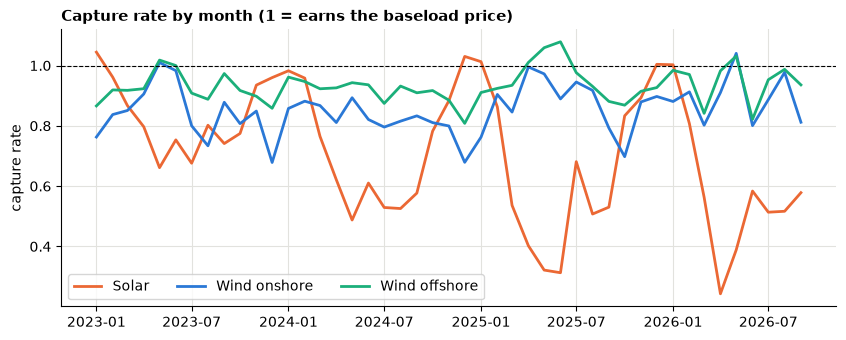

In [23]:
TECHS = ["solar", "wind_onshore", "wind_offshore"]   # any of: solar, wind_onshore, wind_offshore
FROM, TO = "2023-01", "2026-09"

rate = monthly["capture_rate"].unstack("technology").loc[FROM:TO]
fig, ax = plt.subplots()
for tech in TECHS:
    ax.plot(rate.index.to_timestamp(), rate[tech], color=COLOURS[tech], linewidth=2, label=LABELS[tech])
ax.axhline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("capture rate"); ax.set_title("Capture rate by month (1 = earns the baseload price)")
ax.legend(ncols=3);

### 2.5 Seasonality: solar capture rate by year and calendar month

In [24]:
solar_m = monthly.xs("solar", level="technology")
season = pd.DataFrame({"year": solar_m.index.year, "month": solar_m.index.month,
                       "rate": solar_m["capture_rate"].to_numpy()})
season.pivot(index="year", columns="month", values="rate").style.format("{:.2f}", na_rep="").background_gradient(cmap="Blues_r", axis=None)

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2023,1.04,0.96,0.87,0.80,0.66,0.75,0.68,0.80,0.74,0.77,0.93,0.96
2024,0.98,0.96,0.76,0.62,0.49,0.61,0.53,0.53,0.58,0.78,0.88,1.03
2025,1.01,0.86,0.54,0.40,0.32,0.31,0.68,0.51,0.53,0.83,0.89,1.00
2026,1.00,0.81,0.56,0.24,0.39,0.58,0.51,0.52,0.58,,,


### 2.6 🎛 Play: cannibalisation
Each point is one month: the technology's share of load against its capture rate.
Try `TECH = "wind_onshore"`: is there cannibalisation for wind too?

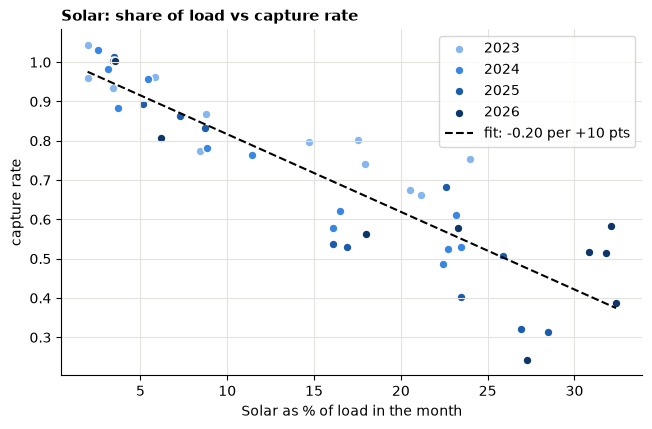

In [25]:
TECH = "solar"

column = TECHNOLOGIES[TECH]
month_of = pd.PeriodIndex(power_loc.index.tz_localize(None), freq="M")
sums = power[[column, "load_mw"]].groupby(month_of).sum()
share = 100 * sums[column] / sums["load_mw"]
data = pd.DataFrame({"share": share, "rate": monthly.xs(TECH, level="technology")["capture_rate"]}).dropna()
slope, intercept = np.polyfit(data["share"], data["rate"], 1)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for year, grp in data.groupby(data.index.year):
    ax.scatter(grp["share"], grp["rate"], s=40, label=str(year), color=YEAR_COLOURS.get(year, "grey"),
               edgecolor="white")
xs = np.linspace(data["share"].min(), data["share"].max(), 50)
ax.plot(xs, intercept + slope * xs, color="black", linestyle="--", label=f"fit: {10 * slope:+.2f} per +10 pts")
ax.set_xlabel(f"{LABELS[TECH]} as % of load in the month"); ax.set_ylabel("capture rate")
ax.set_title(f"{LABELS[TECH]}: share of load vs capture rate"); ax.legend();

### 2.7 Against the official market values (netztransparenz.de)
Difference = ours − official, in ct/kWh. Spot should be ~0 everywhere except June 2024.

In [26]:
official = load_market_values(s.reference_dir / "netztransparenz_market_values_monthly.csv")
in_range = monthly.index.get_level_values("period") <= official.index.max()
comparison = compare_monthly(monthly[in_range], official)
diff = comparison.pivot(index="month", columns="series", values="difference_ct_kwh")
diff.describe().loc[["mean", "min", "max"]].round(3)

series,solar,spot,wind_offshore,wind_onshore
mean,0.067,-0.026,0.533,0.306
min,-0.188,-1.156,-0.001,-0.372
max,0.590,0.000,1.646,1.428


In [27]:
# The one spot-price break: 26 June 2024, SDAC partial decoupling. Our source has the Nord Pool result.
day = prices_h_loc.loc["2024-06-26", "price_eur_mwh"]
print(f"Our daily mean on 26 Jun 2024: {day.mean():.2f} EUR/MWh (EPEX cleared about 492, Nord Pool about 103)")
print(f"June 2024 spot, ours minus official: {diff.loc[pd.Period('2024-06', 'M'), 'spot']:+.3f} ct/kWh")

Our daily mean on 26 Jun 2024: 103.01 EUR/MWh (EPEX cleared about 492, Nord Pool about 103)
June 2024 spot, ours minus official: -1.156 ct/kWh


### 2.8 🎛 Play: one day in quarter-hours (solar vs price)
By default: the 2026 day with the most negative quarter-hours. Set `DAY` to any date
(after 1 Oct 2025 you see true quarter-hour prices).

2026-04-05: base -16.34 EUR/MWh | solar capture -62.07 EUR/MWh | solar energy at negative prices 99%


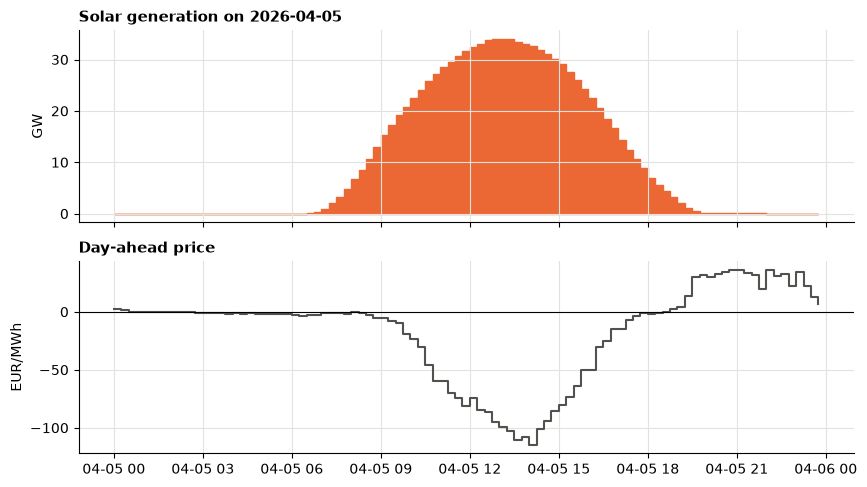

In [28]:
DAY = None                 # e.g. "2026-05-01"; None = most negative day of 2026

if DAY is None:
    neg = (prices_loc.loc["2026", "price_eur_mwh"] < 0)
    DAY = str(neg.groupby(neg.index.date).sum().idxmax())

p = prices_on_grid(prices, power.index).tz_convert(TZ).loc[DAY]
g = power_loc.loc[DAY, "solar_mw"]
day_capture = (p * g).sum() / g.sum()
print(f"{DAY}: base {p.mean():.2f} EUR/MWh | solar capture {day_capture:.2f} EUR/MWh | "
      f"solar energy at negative prices {g[p < 0].sum() / g.sum():.0%}")

fig, (top, bottom) = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
top.fill_between(g.index, g / 1e3, color=COLOURS["solar"], step="post"); top.set_ylabel("GW")
top.set_title(f"Solar generation on {DAY}")
bottom.step(p.index, p, where="post", color="#52514e"); bottom.axhline(0, color="black", linewidth=0.8)
bottom.set_ylabel("EUR/MWh"); bottom.set_title("Day-ahead price");

### Day 2: play ideas (no answers here, explore)
- Is the solar capture rate different on **weekends** than on weekdays? (Hint: filter `power` and
  `prices` before `capture_table`.)
- If negative prices were **floored at 0**, how much would the 2025 solar capture price rise?
- Which **month** of 2025 had the biggest gap between wind onshore and offshore capture rates? Why?
- Compute the **capture rate of load** itself (`load_mw` as the "generation"). Is it above or below 1?
  What does that tell a retailer?
- Use 2.8 to look at a **winter** day: why is the solar capture rate close to 1 there?

#### ✍ Your turn (Day 2)

In [29]:
# your code here

### ✅ My solutions: Day 2 exercises
Live from `exercises/day02_capture.py`: edit that file, then re-run these cells. Unsolved
exercises show ⏳ and fill in automatically once you solve them. The automatic checks run first.

In [30]:
ex2 = load_exercises("day02_capture")
run_checks("test_day02_capture.py")

✅ test_ex1_solar_july_2024
✅ test_ex1_wind_onshore_january_2025
✅ test_ex2_solar_energy_at_negative_prices
✅ test_ex3_solar_profile_cost_tripled_from_2023_to_2025


**Exercise 1: one capture price by hand.** Then your hourly function against the library's
quarter-hour method for every month of 2024: they must agree, because before 1 Oct 2025 each
hour has one price.

In [31]:
july = solution(ex2.capture_price_month, prices_h, power_h, "solar_mw", 2024, 7)
if july is not None:
    print(f"Solar, July 2024: {july:.2f} EUR/MWh (official MW Solar: 35.54)")
    mine = pd.Series({pd.Period(f"2024-{m:02d}", "M"): ex2.capture_price_month(prices_h, power_h, "solar_mw", 2024, m)
                      for m in range(1, 13)})
    library = monthly.xs("solar", level="technology")["capture_price_eur_mwh"].reindex(mine.index)
    display(pd.DataFrame({"yours (hourly)": mine, "library (15-min)": library, "difference": (mine - library).round(6) + 0.0}).round(3))  # + 0.0 turns -0.0 into 0.0

def capture_price_month(
    prices: pd.DataFrame, power: pd.DataFrame, column: str, year: int, month: int
) -> float:
    """Volume-weighted price (EUR/MWh) earned by one technology in one local month.

        capture price = sum(price_h * energy_h) / sum(energy_h)

    Example call: capture_price_month(prices, power, "solar_mw", 2024, 7)

    Hints:
      1. Convert both frames to local time with .tz_convert(TZ).
      2. Select the month with .loc[f"{year}-{month:02d}"].
      3. Multiply the two Series (pandas aligns them on the index), sum, divide.
    """
    prices_local = prices.tz_convert(TZ)
    power_local = power.tz_convert(TZ)

    month_str = f"{year}-{month:02d}"
    p = prices_local.loc[month_str,"price_eur_mwh"]
    e = power_local.loc[month_str,column]
    return float((p * e).sum() / e.sum())

Solar, July 2024: 35.82 EUR/MWh (official MW Solar: 35.54)


,yours (hourly),library (15-min),difference
2024-01,75.232,75.232,0.0
2024-02,58.773,58.773,0.0
2024-03,49.487,49.487,0.0
2024-04,38.732,38.732,0.0
2024-05,32.768,32.768,0.0
2024-06,44.473,44.473,0.0
2024-07,35.820,35.820,0.0
2024-08,43.125,43.125,0.0
2024-09,45.172,45.172,0.0
2024-10,67.357,67.357,0.0


**Exercise 2: energy at negative prices**, for all three technologies.

In [32]:
share = solution(ex2.negative_price_energy_share, prices_h, power_h, "solar_mw", 2025)
if share is not None:
    shares = pd.DataFrame({LABELS[t]: {y: ex2.negative_price_energy_share(prices_h, power_h, col, y)
                                       for y in (2023, 2024, 2025)} for t, col in TECHNOLOGIES.items()})
    display(shares.map("{:.1%}".format))

def negative_price_energy_share(
    prices: pd.DataFrame, power: pd.DataFrame, column: str, year: int
) -> float:
    """Share (0 to 1) of a technology's energy in one local year produced in hours
    whose hourly price is below zero.

    Why it matters: since 2025, new EEG plants get no market premium in negative
    periods, and a pay-as-produced PPA buyer pays the fixed price for these MWh
    although they are worth less than nothing on the spot market.

    Hints:
      1. Same selection as in exercise 1, but for a whole year: .loc[str(year)].
      2. Boolean mask: price < 0. Energy in those hours / total energy.
    """
    prices_local = prices.tz_convert(TZ).loc[str(year)]
    power_local = power.tz_convert(TZ).loc[str(year)]

    p = prices_local["price_eur_mwh"]
    e = power_local[column]
    negative = p<0
    return float(e[negative].sum()/e.sum())

,Solar,Wind onshore,Wind offshore
2023,8.3%,5.8%,4.1%
2024,18.3%,6.3%,4.6%
2025,24.2%,7.7%,4.5%


**Exercise 3: profile cost** in EUR billion, for all three technologies.

def profile_cost_eur_bn(prices: pd.DataFrame, power: pd.DataFrame, column: str, year: int) -> float:
    """How much less (in billion EUR) all German plants of one technology earned in one
    local year than if their energy had been sold at the baseload price:

        profile cost = (base price - capture price) * energy

    Base price = simple mean of the hourly prices of that year (time-weighted).
    Units: EUR/MWh * MWh = EUR; divide by 1e9 for EUR bn.

    Hints:
      1. Reuse your logic from exercise 1 for the capture price of the year.
      2. Energy in MWh = sum of the hourly MW values.
    """
    prices_local = prices.tz_convert(TZ).loc[str(year)]
    power_local = power.tz_convert(TZ).loc[str(year)]

    p = prices_local["price_eur_mwh"]
    e = power_local[column]

    capture = (p*e).sum() / e.sum()
    base = p.mean()
    energy = e.sum()
    return float((base-capture)*energy / 1e9)

,Solar,Wind onshore,Wind offshore
2023,1.24,1.94,0.20
2024,1.91,1.55,0.18
2025,3.03,1.27,0.10


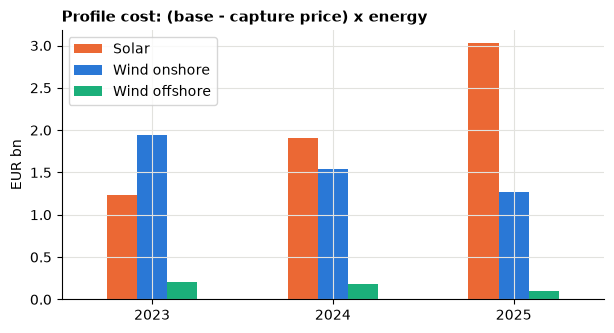

In [33]:
cost = solution(ex2.profile_cost_eur_bn, prices_h, power_h, "solar_mw", 2025)
if cost is not None:
    costs = pd.DataFrame({t: {y: ex2.profile_cost_eur_bn(prices_h, power_h, col, y) for y in (2023, 2024, 2025)}
                          for t, col in TECHNOLOGIES.items()})
    display(costs.rename(columns=LABELS).round(2))
    ax = costs.plot.bar(color=[COLOURS[t] for t in costs.columns], rot=0, figsize=(7, 3.5))
    ax.legend([LABELS[t] for t in costs.columns]); ax.set_ylabel("EUR bn")
    ax.set_title("Profile cost: (base - capture price) x energy");

**Exercise 4 (written): hourly vs quarter-hourly**

In [34]:
show_written_answer("day02_capture.py", "# Your answer:")

> Until 30 Sep 2025 the day-ahead price was hourly, so all four quarter-hours of an hour have
> the same price; then sum(price x quarter-hour energy) = price x hourly energy, and the hourly
> and quarter-hourly methods are mathematically identical (2024: 35.82 both ways in July).
> From 1 Oct 2025 each quarter-hour has its own price. Averaging prices and energy to hours
> first ignores how output and price move together inside the hour: solar ramps up while
> quarter-hour prices fall (and down while they rise), a negative within-hour covariance, so
> the hourly method overstates the solar capture price (Oct-Dec 2025: +0.7 to +1.4 EUR/MWh).
> For the whole of 2025 the gap is only 0.12 EUR/MWh because just Oct-Dec are affected and
> they carry 7 of 70 TWh of solar. The TSOs use quarter-hours, as EEG 2023 Anlage 1 requires
> ("fuer jede Viertelstunde"), and so does our report.

---
# Day 3: PPA pricing maths (PPA-3)

*Added on Day 3.*